In [1]:
import yfinance as yf
import pandas as pd

# ETF ticker
ticker = "BOTZ"

# veriyi indir (2005'ten başlatıyoruz ama ETF 2016'da başlar)
data = yf.download(ticker, start="2005-01-01")

# sadece kapanış fiyatı
df = data[["Close"]].copy()

# index tarih -> datetime
df.index = pd.to_datetime(df.index)

# aylık kapanış fiyatı
monthly = df.resample("M").last()

# year ve month ayır
monthly["year"] = monthly.index.year
monthly["month"] = monthly.index.month

# ay-yıl string formatı
monthly["month_year"] = monthly.index.strftime("%Y-%m")

# sadece gerekli kolonlar
monthly = monthly[["month_year", "Close"]]

# kolon adı değiştir
monthly.rename(columns={"Close": "botz_price"}, inplace=True)

# csv kaydet
monthly.to_csv("botz_monthly_price.csv", index=False)

print("BOTZ monthly dataset created")
print(monthly.head())

[*********************100%***********************]  1 of 1 completed

BOTZ monthly dataset created
Price      month_year botz_price
Ticker                      BOTZ
Date                            
2016-09-30    2016-09  14.699145
2016-10-31    2016-10  14.420717
2016-11-30    2016-11  14.478322
2016-12-31    2016-12  14.410190
2017-01-31    2017-01  15.673486



/var/folders/tw/fj_7vnxd7hn8ldfhpr2qlbnm0000gn/T/ipykernel_34474/2703715242.py:17: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df.resample("M").last()


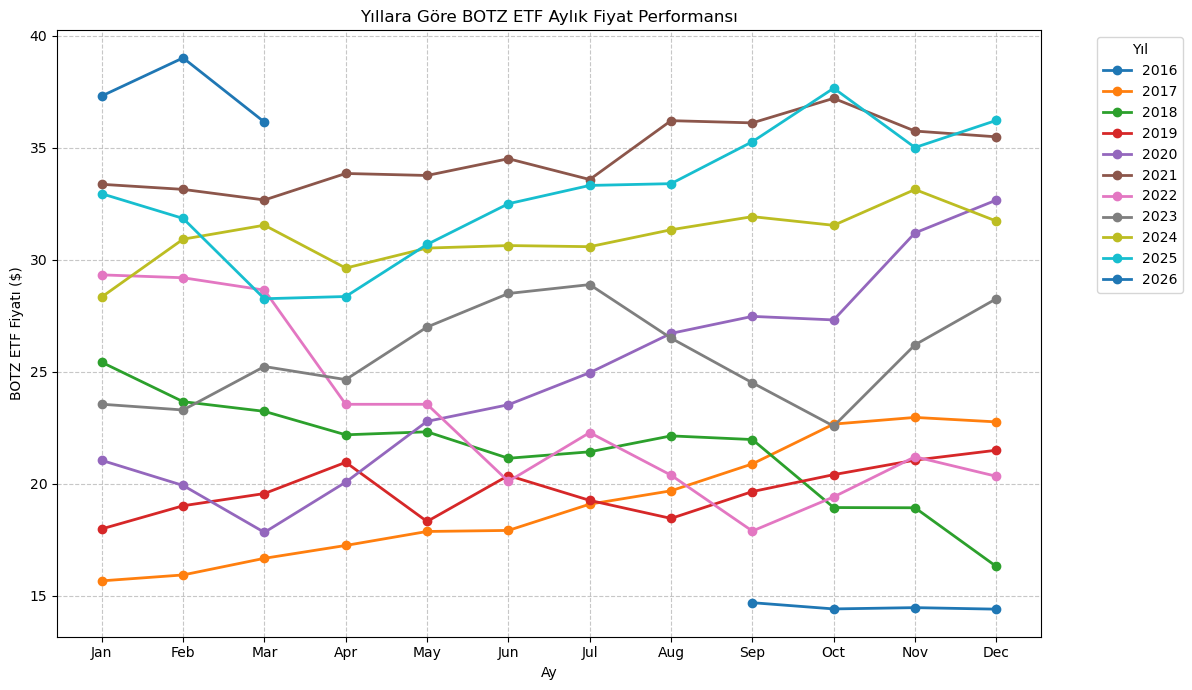

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Veriyi Oku
df = pd.read_csv("botz_monthly_price.csv")

# 2. Veri Temizleme ve Tip Dönüşümü
# Fiyat sütununu sayıya çevir (Hatalı metinleri/yazıları NaN yapar)
df["botz_price"] = pd.to_numeric(df["botz_price"], errors='coerce')

# Boş (NaN) olan veya hatalı olan satırları temizle
# Bu adım, dosyadaki ilk "BOTZ" metni olan satırı eler
df = df.dropna(subset=["botz_price", "month_year"])

# Yıl ve ay bilgisini ayır
df["year"] = df["month_year"].str[:4].astype(int)
df["month_num"] = df["month_year"].str[5:7].astype(int)

# Grafik ekseni için ay isimleri
month_names = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

# 3. Görselleştirme
plt.figure(figsize=(12, 7))

# Her yılın verisini döngüyle grafiğe ekle
for year in sorted(df["year"].unique()):
    # O yıla ait veriyi seç ve aylara göre sırala
    year_data = df[df["year"] == year].sort_values("month_num")
    
    plt.plot(
        year_data["month_num"],
        year_data["botz_price"],
        marker="o",
        linewidth=2,
        label=str(year)
    )

# Grafik Ayarları
plt.xlabel("Ay")
plt.ylabel("BOTZ ETF Fiyatı ($)")
plt.title("Yıllara Göre BOTZ ETF Aylık Fiyat Performansı")

# X eksenindeki 1-12 arası rakamları ay isimleriyle değiştir
plt.xticks(range(1, 13), month_names)

# Yıl listesini (legend) grafiğin sağına yerleştir
plt.legend(title="Yıl", bbox_to_anchor=(1.05, 1), loc='upper left')

# Izgara çizgileri ekle
plt.grid(True, linestyle='--', alpha=0.7)

# Grafik etrafındaki boşlukları düzenle
plt.tight_layout()

# Grafiği göster veya kaydet
plt.show()

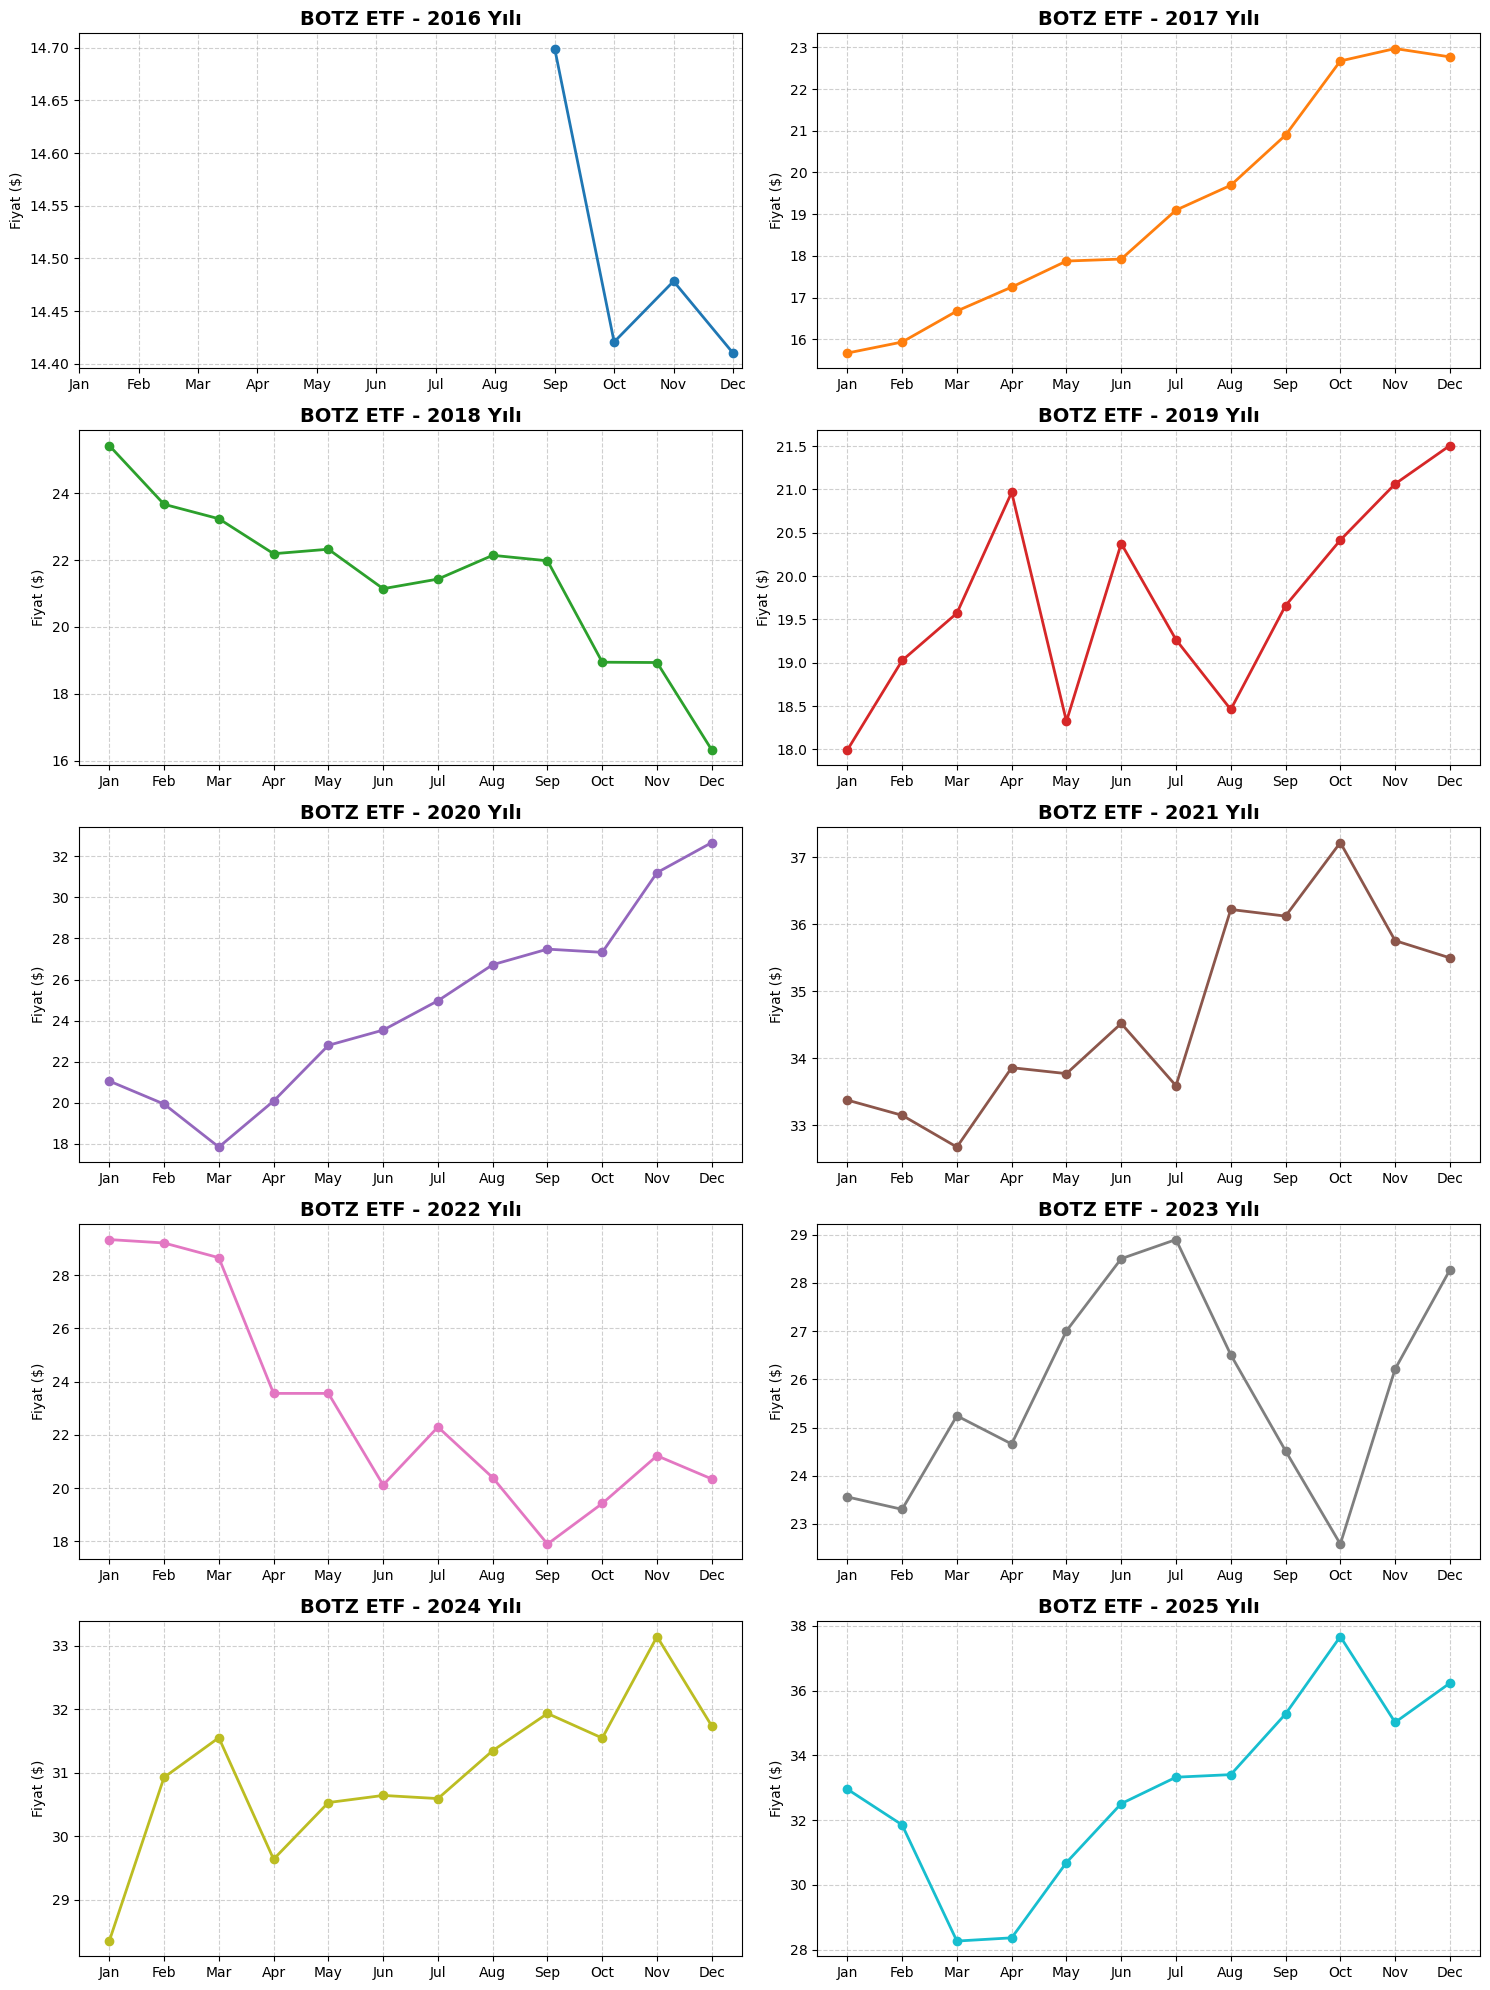

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import math

# 1. Veriyi Oku
df = pd.read_csv("botz_monthly_price.csv")

# 2. Veri Temizleme ve Hazırlık
df["botz_price"] = pd.to_numeric(df["botz_price"], errors='coerce')
df = df.dropna(subset=["botz_price", "month_year"])

# Yıl ve ay ayır
df["year"] = df["month_year"].str[:4].astype(int)
df["month_num"] = df["month_year"].str[5:7].astype(int)

# 2026 yılını hariç tut (istediğiniz üzerine)
df = df[df["year"] < 2026]

# Yılları al
years = sorted(df["year"].unique())
num_years = len(years)

# 3. Görselleştirme (Her yıl için ayrı subplot)
# 2 sütunlu bir yapı oluşturalım, satır sayısı yıl sayısına göre otomatik hesaplanır
cols = 2
rows = math.ceil(num_years / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
axes = axes.flatten() # Eksen matrisini tek boyutlu listeye çevirir

month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

for i, year in enumerate(years):
    year_data = df[df["year"] == year].sort_values("month_num")
    ax = axes[i]
    
    ax.plot(year_data["month_num"], year_data["botz_price"], marker='o', color='C'+str(i), linewidth=2)
    ax.set_title(f"BOTZ ETF - {year} Yılı", fontsize=14, fontweight='bold')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_names)
    ax.set_ylabel("Fiyat ($)")
    ax.grid(True, linestyle='--', alpha=0.6)

# Eğer yıl sayısı tekse, boş kalan son grafiği gizle
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [7]:
import pandas as pd

# Load the AI papers dataset
papers_df = pd.read_csv("ai_monthly_papers.csv")
print("AI Papers Dataset Info:")
print(papers_df.info())
print("\nFirst 10 rows of AI Papers:")
print(papers_df.head(10))

# Load the BOTZ price dataset for reference
botz_df = pd.read_csv("botz_monthly_price.csv")
print("\nBOTZ Price Dataset Info:")
print(botz_df.info())
print("\nFirst 10 rows of BOTZ Price:")
print(botz_df.head(10))

AI Papers Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255 entries, 0 to 254
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   month        255 non-null    object
 1   paper_count  255 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 4.1+ KB
None

First 10 rows of AI Papers:
     month  paper_count
0  2005-01           12
1  2005-02           19
2  2005-03            9
3  2005-04           23
4  2005-05           11
5  2005-06            8
6  2005-07           15
7  2005-08           10
8  2005-09           11
9  2005-10           14

BOTZ Price Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116 entries, 0 to 115
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   month_year  115 non-null    object
 1   botz_price  116 non-null    object
dtypes: object(2)
memory usage: 1.9+ KB
None

First 10 rows of BOTZ Pr